# GEEZ OCR

Ge'ez an ancient South Semitic language that originated in the Horn of Africa, specifically northern Ethiopia and southern Eritrea. It is the historical root or primary influence for modern Horn of African languages like Amharic, Tigrinya, and Tigré. t preserves centuries of invaluable historical chronicles, philosophical works, traditional medicine, and unique religious texts (including the Ge'ez Bible). It contain around 287 characters featuring 34 core base consonants, with each expanding into 7 vowel forms (orders) and irregular characters.

This project is going to use [Yaredoffice/geez-characters](https://huggingface.co/datasets/Yaredoffice/geez-characters) dataset to train an OCR model. The dataset was downloaded to the project in order to preprocess it and handle class label inference. 

## Import the necessary libraries and utility functions

In [1]:
%load_ext autoreload
%autoreload 2
import tensorflow as tf
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt
from utils import *
from models.ann_models import *
from models.cnn_models import *

## 1. Load and Explore the Dataset

### 1.1. Load the data

In [58]:
(X_train, y_train, train_paths), (X_test, y_test, test_paths)  = load_data("dataset")

Found 13776 files belonging to 287 classes.
Found 1435 files belonging to 287 classes.


### 1.2. Explore the data

In [3]:
print(f"X_train.shape  = {X_train.shape}")
print(f"Y_train.shape = {y_train.shape}")
print(f"X_test.shape  = {X_test.shape}")
print(f"Y_test.shape = {y_test.shape}")

print(f"X_train[0] is: \n{X_train[0]}\n")
print(f"X_train[-1] is: \n{X_train[-1]}\n")
print(f"Y_train[0] is: \n{y_train[0]}\n")
print(f"Y_train[-1] is: \n{y_train[-1]}\n")

X_train.shape  = (13776, 32, 32, 1)
Y_train.shape = (13776,)
X_test.shape  = (1435, 32, 32, 1)
Y_test.shape = (1435,)
X_train[0] is: 
[[[237.     ]
  [249.09375]
  [255.     ]
  ...
  [254.45312]
  [254.32812]
  [255.     ]]

 [[237.67188]
  [249.31421]
  [255.     ]
  ...
  [254.45312]
  [254.10767]
  [254.32812]]

 [[237.54688]
  [249.2732 ]
  [254.38403]
  ...
  [253.34155]
  [253.39111]
  [254.     ]]

 ...

 [[238.34375]
  [249.53467]
  [254.29907]
  ...
  [251.5647 ]
  [252.8584 ]
  [255.     ]]

 [[229.04688]
  [246.26367]
  [253.31958]
  ...
  [250.02368]
  [251.75342]
  [254.67188]]

 [[223.     ]
  [243.82812]
  [251.73438]
  ...
  [251.     ]
  [251.98438]
  [254.     ]]]

X_train[-1] is: 
[[[255.]
  [255.]
  [255.]
  ...
  [255.]
  [255.]
  [255.]]

 [[255.]
  [255.]
  [255.]
  ...
  [255.]
  [255.]
  [255.]]

 [[255.]
  [255.]
  [255.]
  ...
  [255.]
  [255.]
  [255.]]

 ...

 [[255.]
  [255.]
  [255.]
  ...
  [255.]
  [255.]
  [255.]]

 [[255.]
  [255.]
  [255.]
  ...
  [

## 1.3. Show randomly selected images
Show randomly selected 20 images from both the training and test datasets with their actual labels to see what the images and characters look like.

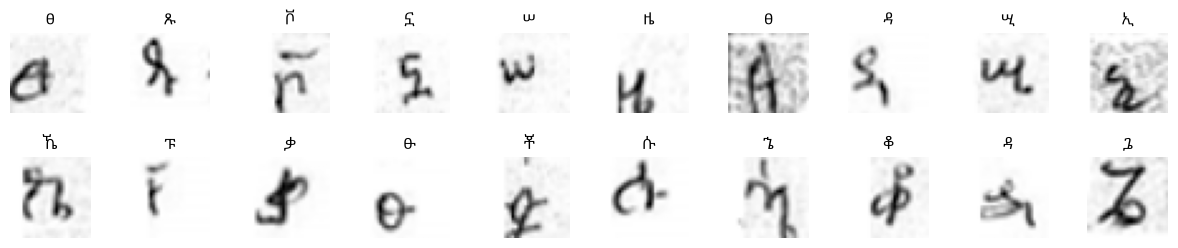

In [4]:
# From the training dataset
show_images(X_train, y_train, num_of_images=20)

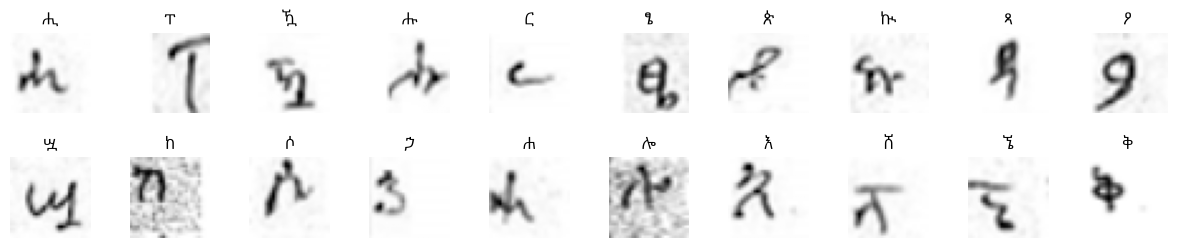

In [5]:
# From the test dataset
show_images(X_test, y_test, num_of_images=20)

## 2. Train and Validate the Models
Since the project is trying out different Artificial Neural Networks and Convolutional Neural Networks to identify Ge'ez characters, we are going to cross validate the models using `Stratified Folds` to test how well the models generalize to new unseen data. 

## 2.1. Overview of the models

### 2.1.1. ANN models

#### 2.1.1.1. Simpler ANN model

In [6]:
simpler_ann = build_simpler_ann()
simpler_ann.summary()

Model: "Basic_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         131,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 287)                 │          18,655 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 158,111 (617.62 KB)

 Trainable params: 158,111 (617.62 KB)

 Non-trainable params: 0 (0.00 B)

#### 2.1.1.2. Deeper ANN Model

In [7]:
deeper_ann_model = build_deeper_ann()
deeper_ann_model.summary()

Model: "Deeper_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 256)                 │         262,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 287)                 │          37,023 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 332,319 (1.27 MB)

 Trainable params: 332,319 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

#### 2.1.1.3. Regularized Deeper ANN Model

In [8]:
regularized_ann_model = build_regularized_deeper_ann()
regularized_ann_model.summary()

Model: "Regularized_Deeper_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 256)                 │         262,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 287)                 │          37,023 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 332,319 (1.27 MB)

 Trainable params: 332,319 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

### 2.1.2. CNN Models

#### 2.1.2.1. Simpler CNN Model

In [9]:
simpler_cnn_model = build_simpler_cnn()
simpler_cnn_model.summary()

Model: "Basic_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 32, 32, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 64)                  │         524,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 287)                 │          18,655 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 543,327 (2.07 MB)

 Trainable params: 543,327 (2.07 MB)

 Non-trainable params: 0 (0.00 B)

#### 2.1.2.2. Deeper CNN Model

In [10]:
deeper_cnn_model = build_deeper_cnn()
deeper_cnn_model.summary()

Model: "Deeper_CNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 128)                 │         524,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 287)                 │          37,023 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 580,255 (2.21 MB)

 Trainable params: 580,255 (2.21 MB)

 Non-trainable params: 0 (0.00 B)

#### 2.1.2.3. Regularized Deeper CNN Model

In [11]:
regularized_deeper_cnn_model = build_regularized_deeper_cnn()
regularized_deeper_cnn_model.summary()

Model: "Regularized_Deeper_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 32, 32, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu (ReLU)                         │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_1 (ReLU)                       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_5 (Flatten)                  │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 128)                 │         524,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 287)                 │          37,023 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 580,639 (2.21 MB)

 Trainable params: 580,447 (2.21 MB)

 Non-trainable params: 192 (768.00 B)

## 2.3 Train the Models using K-fold

### 2.2.1 Train ANN Models using K-folds

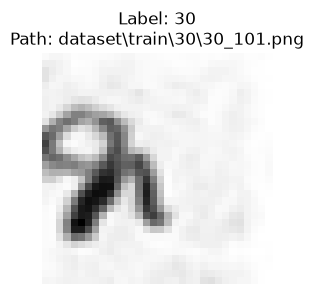

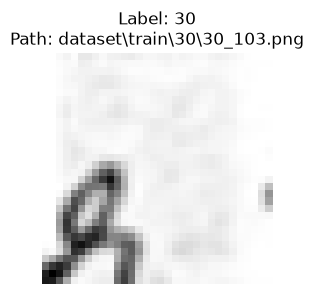

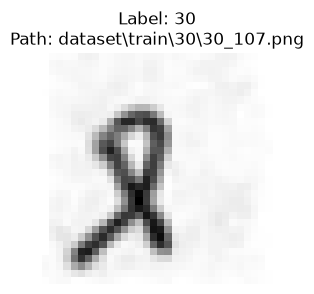

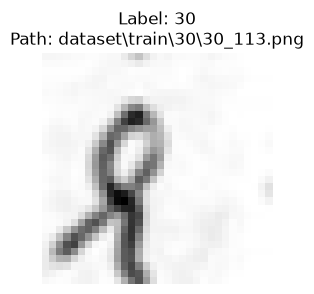

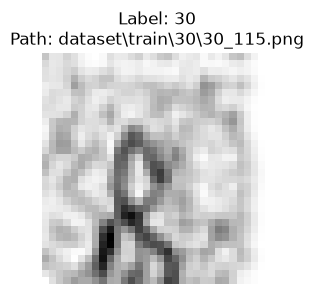

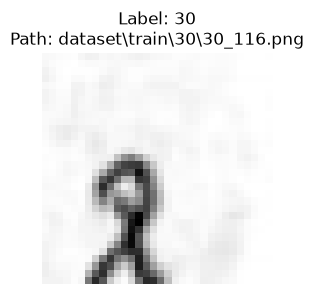

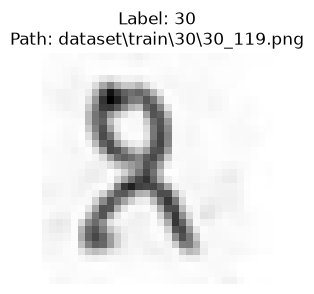

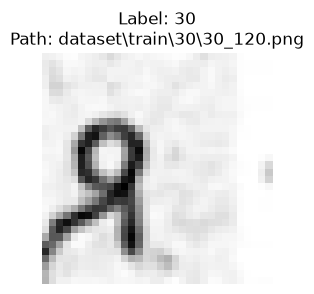

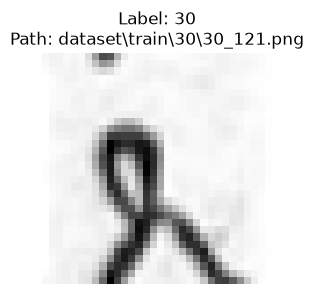

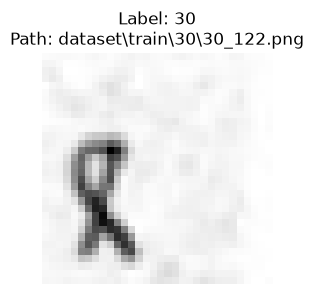

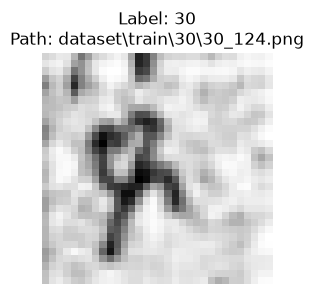

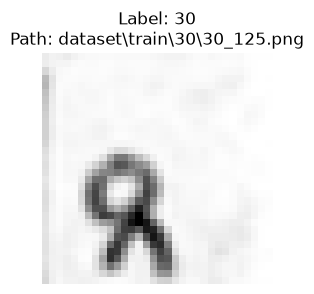

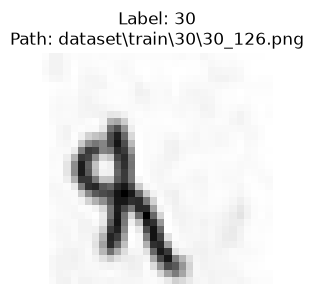

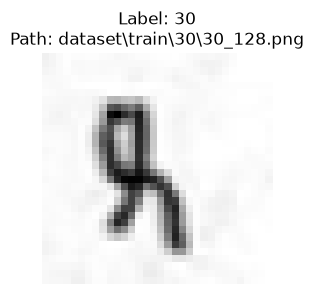

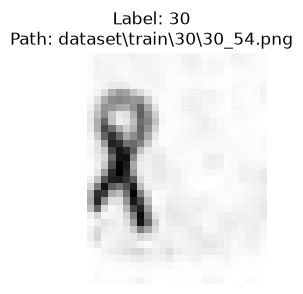

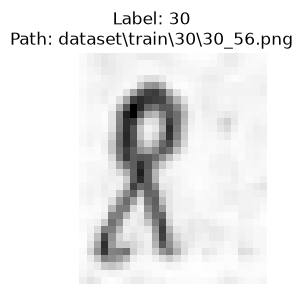

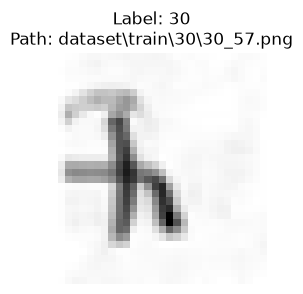

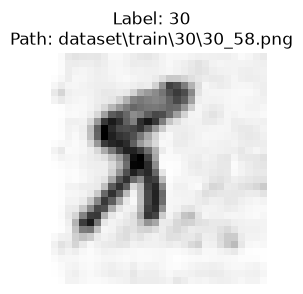

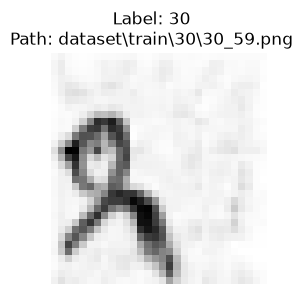

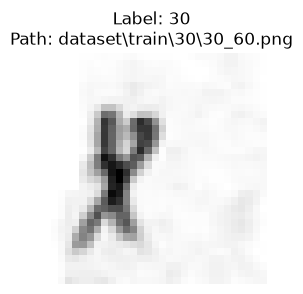

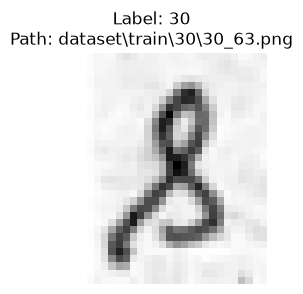

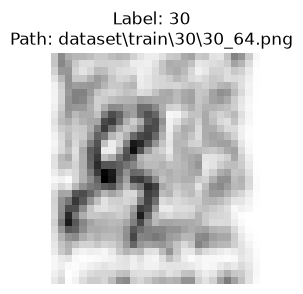

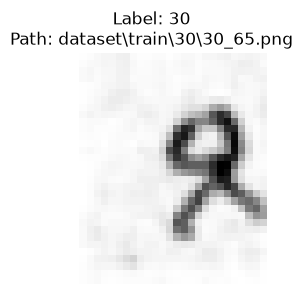

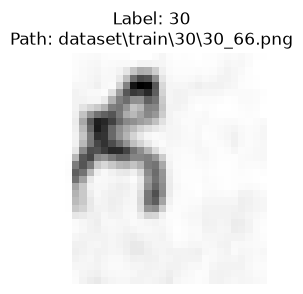

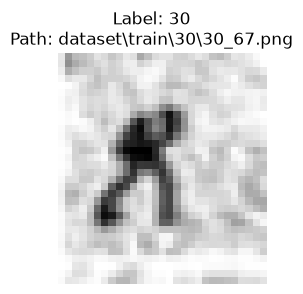

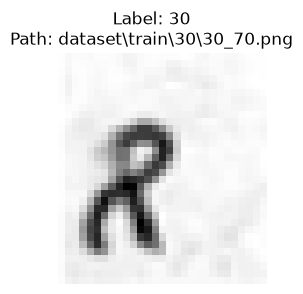

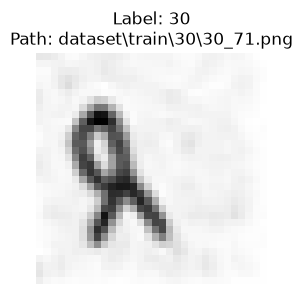

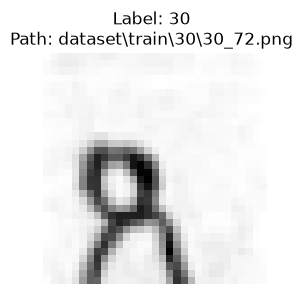

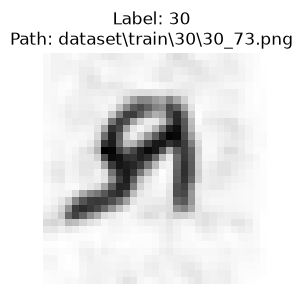

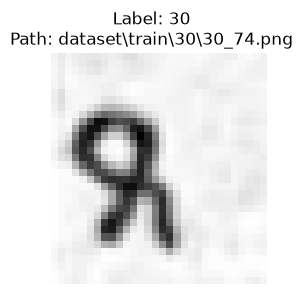

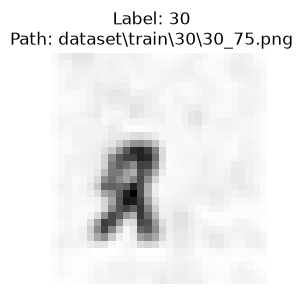

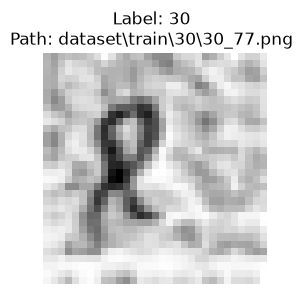

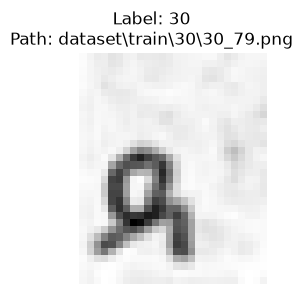

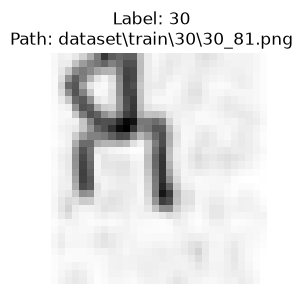

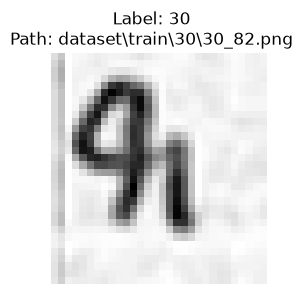

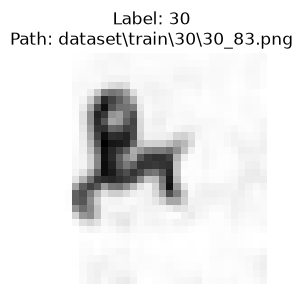

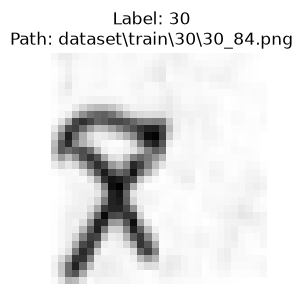

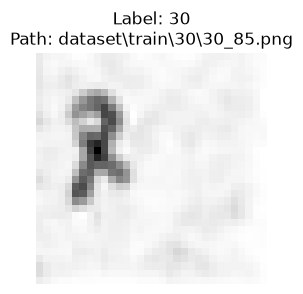

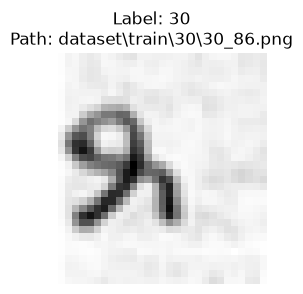

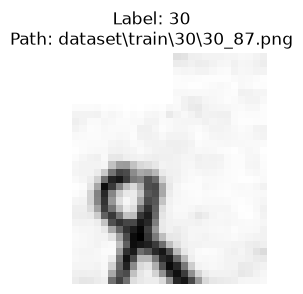

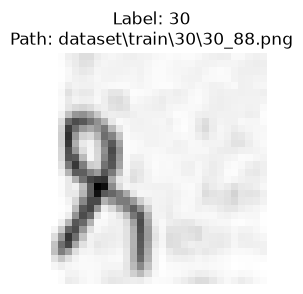

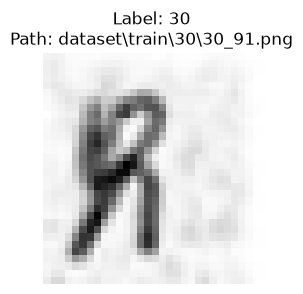

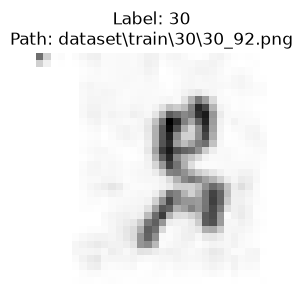

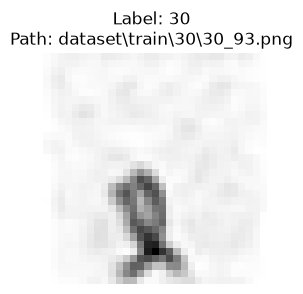

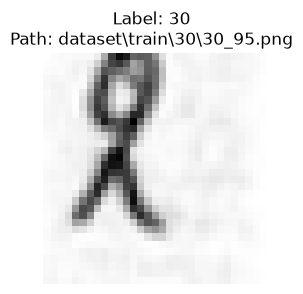

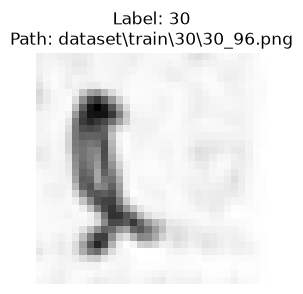

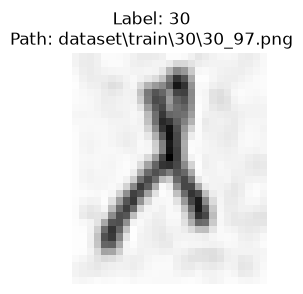

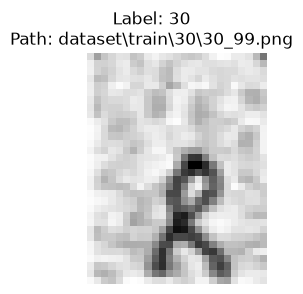

In [99]:
# j = 30
# for i in range(j*48, j*48 + 48):
#     plt.figure(figsize=(3, 3))
#     plt.imshow(X_train[i].squeeze(), cmap="gray")
#     plt.title(
#         f"Label: {y_train[i]}\n"
#         f"Path: {train_paths[i]}"
#     )
#     plt.axis("off")
#     plt.show()
x_debug = X

In [13]:
ann_models = {
    "Simpler ANN Model": build_simpler_ann,
    "Deeper ANN Model": build_deeper_ann,
    "Regularized ANN Model": build_regularized_deeper_ann
}

# Store the summarized results of the ann models
ann_results = {}

for name, build_model in ann_models.items():
    # Styling
    print("\n\n")
    print("=" * 50)
    print(name)
    print("=" * 50)
    
    results = cross_validate_model(
        build_model,
        X_train,
        y_train,
        epochs=10
    )
    
    ann_results[name] = summarize_results(results)




Simpler ANN Model

========== Fold 1 ==========
Epoch 1/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.0030 - loss: 5.6681 - val_accuracy: 0.0033 - val_loss: 5.6595
Epoch 2/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0015 - loss: 5.6600 - val_accuracy: 0.0033 - val_loss: 5.6595
Epoch 3/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0027 - loss: 5.6600 - val_accuracy: 0.0033 - val_loss: 5.6596
Epoch 4/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0020 - loss: 5.6599 - val_accuracy: 0.0033 - val_loss: 5.6596
Epoch 5/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0025 - loss: 5.6599 - val_accuracy: 0.0033 - val_loss: 5.6596
Epoch 6/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0025 - loss: 5.6599 - val_accuracy: 0.0033 - val_loss: 5.6596
Epoch 7/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0019 - loss: 5.6599 - val_accuracy: 0.0033 - val_loss: 5.6596
Epoch 8/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step -

ቨ


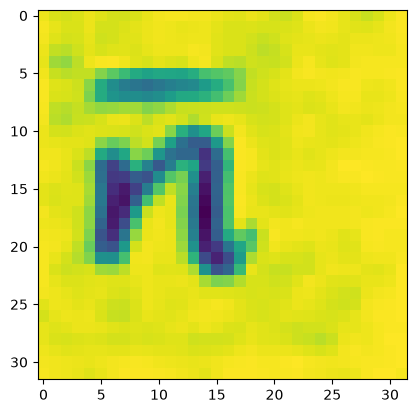

In [74]:
i = 10
print(GEEZ_CHARACTERS[i])
plt.imshow(X_train[i*48])